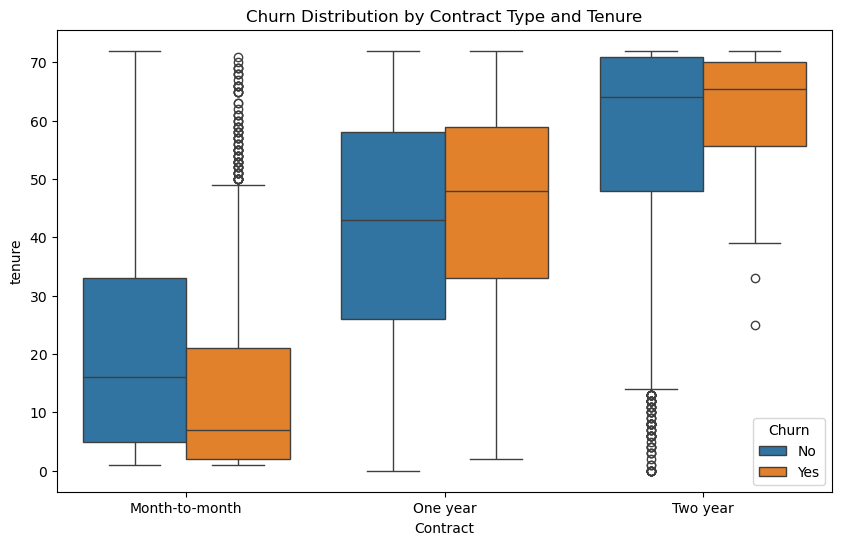

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Handle the 11 blank rows in TotalCharges: 
# Since tenure is 0 for all these, we set TotalCharges to 0 as a deliberate business rule.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Visualization 1: Churn by Contract Type and Tenure
# Hypothesis: Month-to-month contracts + low tenure are the 'danger zone'
plt.figure(figsize=(10, 6))
sns.boxplot(x='Contract', y='tenure', hue='Churn', data=df)
plt.title('Churn Distribution by Contract Type and Tenure')
plt.show()

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Drop the redundant collinear feature
# 1. Drop the redundant collinear feature (Defensive against multiple cell runs)
df = df.drop(columns=['TotalCharges', 'customerID'], errors='ignore')

# 2. One-Hot Encoding (Defensive setup for linear models)
# Dropping the first column avoids perfect multicollinearity 
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Churn') # Keep target separate

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convert target to binary
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

# 3. Strict Stratified Splitting
# Preserving the exact 73.5% / 26.5% real-world distribution
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, roc_auc_score

# ==========================================
# 1. DEFENSIVE SCALING (Preventing Data Leakage)
# ==========================================
scaler = RobustScaler()
cols_to_scale = ['tenure', 'MonthlyCharges']

# Fit on train, transform on train AND test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# ==========================================
# 2. THE BASELINE (Inference & Interpretability)
# ==========================================
# class_weight='balanced' ensures the model doesn't optimize for accuracy by ignoring the 26.5% churn minority
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Extracting the business logic: Converting log-odds to Odds Ratios (e^beta)
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_model.coef_[0],
    'Odds_Ratio': np.exp(lr_model.coef_[0])
}).sort_values(by='Coefficient', ascending=False)

print("--- Top 5 Churn Drivers (Risk Factors) ---")
print(coefficients.head(5).to_string(index=False))

print("\n--- Top 5 Retention Drivers (Protective Factors) ---")
print(coefficients.tail(5).to_string(index=False))

# ==========================================
# 3. THE ADVANCED ENGINE (Non-Linear Interactions)
# ==========================================
# We use Random Forest to capture complex intersections (e.g., month-to-month AND low tenure AND Fiber optic)
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    max_depth=7, # Defensive constraint to prevent overfitting the noise
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

# Quick Validation Check
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Random Forest Validation ---")
print(classification_report(y_test, rf_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}")

--- Top 5 Churn Drivers (Risk Factors) ---
                       Feature  Coefficient  Odds_Ratio
   InternetService_Fiber optic     1.111736    3.039629
PaymentMethod_Electronic check     0.398898    1.490181
           StreamingMovies_Yes     0.392476    1.480643
               StreamingTV_Yes     0.367988    1.444824
          PaperlessBilling_Yes     0.332103    1.393896

--- Top 5 Retention Drivers (Protective Factors) ---
           Feature  Coefficient  Odds_Ratio
OnlineSecurity_Yes    -0.348389    0.705824
    MonthlyCharges    -0.470844    0.624475
 Contract_One year    -0.728844    0.482466
            tenure    -1.406188    0.245076
 Contract_Two year    -1.413148    0.243376

--- Random Forest Validation ---
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      14

<Figure size 800x600 with 0 Axes>

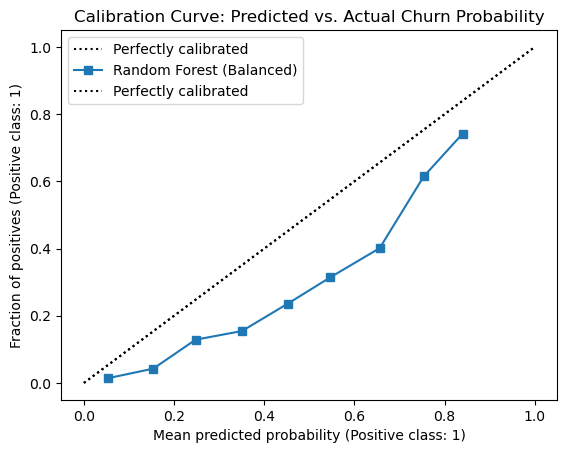

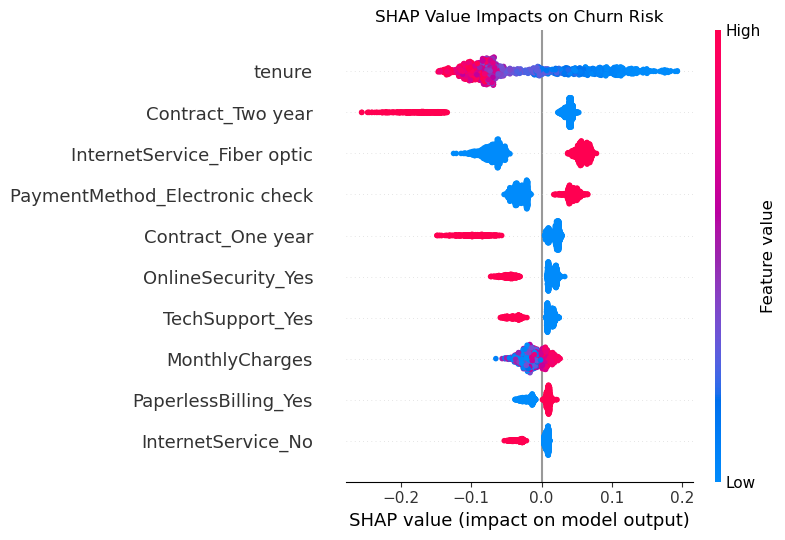

In [11]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay
import shap

# ==========================================
# 1. MODEL CALIBRATION (Reliability Check)
# ==========================================
plt.figure(figsize=(8, 6))
CalibrationDisplay.from_estimator(rf_model, X_test_scaled, y_test, n_bins=10, name='Random Forest (Balanced)')
plt.title("Calibration Curve: Predicted vs. Actual Churn Probability")
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.legend()
plt.show()

# ==========================================
# 2. SHAP ANALYSIS (Human-in-the-Loop Interpretability)
# ==========================================
# We use a TreeExplainer for the Random Forest to extract exact feature contributions
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set (this takes a few seconds)
# We take the values for Class 1 (Churn)
shap_values = explainer.shap_values(X_test_scaled)
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1] 
else:
    # Depending on SHAP version, it might return a 3D array
    shap_values_churn = shap_values[:, :, 1] 

# Generate the Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_churn, X_test_scaled, max_display=10, show=False)
plt.title("SHAP Value Impacts on Churn Risk")
plt.tight_layout()
plt.show()

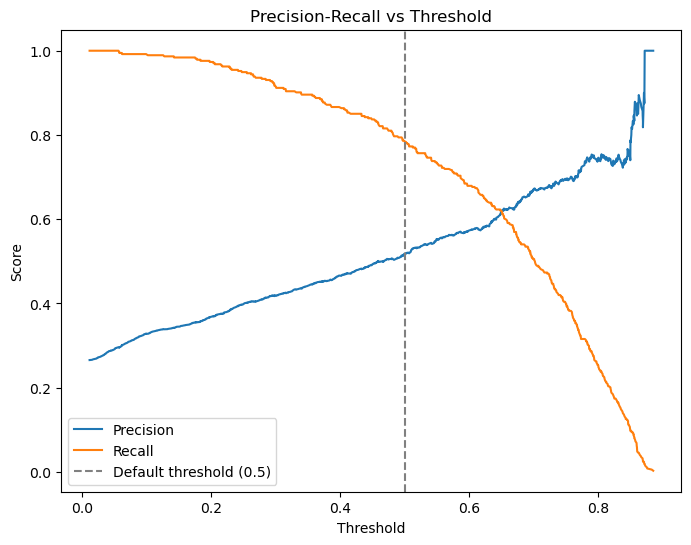

Threshold for ~80% recall: 0.483
Precision at that threshold: 0.504

--- Classification Report at Tuned Threshold ---
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [10]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, rf_probs)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.show()

# Pick a threshold that catches ~80% of churners
target_recall = 0.80
idx = np.argmin(np.abs(recalls - target_recall))
chosen_threshold = thresholds[idx]
print(f"Threshold for ~{target_recall*100:.0f}% recall: {chosen_threshold:.3f}")
print(f"Precision at that threshold: {precisions[idx]:.3f}")

y_pred_tuned = (rf_probs >= chosen_threshold).astype(int)
print("\n--- Classification Report at Tuned Threshold ---")
print(classification_report(y_test, y_pred_tuned))

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score
import shap
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
xgb_preds = xgb_model.predict(X_test_scaled)

lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_preds = lr_model.predict(X_test_scaled)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, xgb_probs)
    ],
    'PR-AUC': [
        average_precision_score(y_test, lr_probs),
        average_precision_score(y_test, rf_probs),
        average_precision_score(y_test, xgb_probs)
    ]
})
print(comparison.to_string(index=False))

              Model  ROC-AUC   PR-AUC
Logistic Regression 0.838663 0.628401
      Random Forest 0.840994 0.639841
            XGBoost 0.834967 0.646062


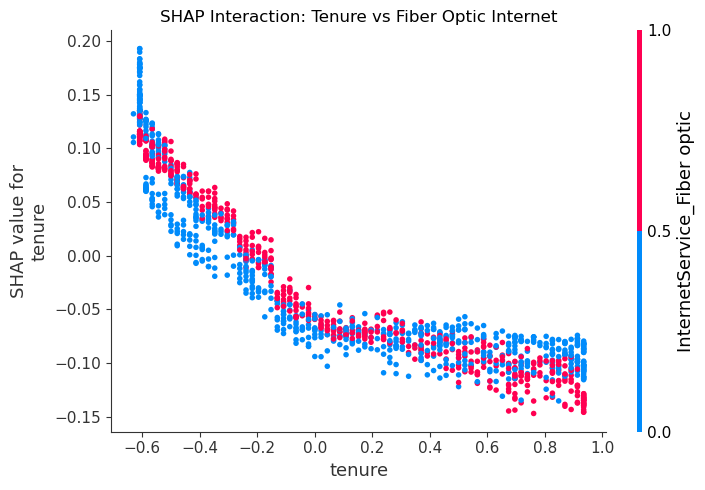

In [20]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values[:, :, 1]

shap.dependence_plot(
    'tenure',
    shap_values_churn,
    X_test_scaled,
    interaction_index='InternetService_Fiber optic',
    show=False
)
plt.title("SHAP Interaction: Tenure vs Fiber Optic Internet")
plt.tight_layout()
plt.show()

      Contract InternetService  Churn_Rate
Month-to-month     Fiber optic    0.546053
Month-to-month             DSL    0.322159
      One year     Fiber optic    0.192950
Month-to-month              No    0.188931
      One year             DSL    0.092982
      Two year     Fiber optic    0.072261
      One year              No    0.024725
      Two year             DSL    0.019108
      Two year              No    0.007837


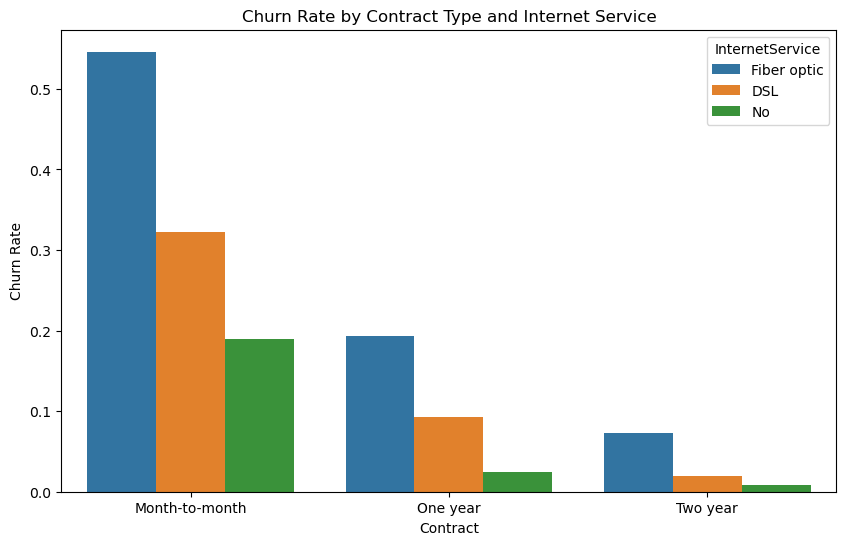

In [22]:
segment_churn = df.groupby(['Contract', 'InternetService'])['Churn'].apply(
    lambda x: (x == 'Yes').mean()
).reset_index(name='Churn_Rate')

segment_churn = segment_churn.sort_values('Churn_Rate', ascending=False)
print(segment_churn.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=segment_churn, x='Contract', y='Churn_Rate', hue='InternetService')
plt.title('Churn Rate by Contract Type and Internet Service')
plt.ylabel('Churn Rate')
plt.show()

 threshold  tp  fp  fn  total_cost
      0.10 370 759   4       58450
      0.15 368 699   6       56350
      0.20 364 624  10       54400
      0.25 355 535  19       54000
      0.30 342 475  32       56850
      0.35 335 422  39       57350
      0.40 323 371  51       60200
      0.45 313 322  61       62250
      0.50 293 274  81       68850
      0.55 274 223 100       74850
      0.60 254 189 120       82150
      0.65 231 143 143       90200
      0.70 189  92 185      106550
      0.75 149  66 225      123250
      0.80  95  33 279      145900
      0.85  38  13 336      170550
      0.90   0   0 374      187000

Optimal cost-based threshold: 0.25 (Total cost: $54,000)


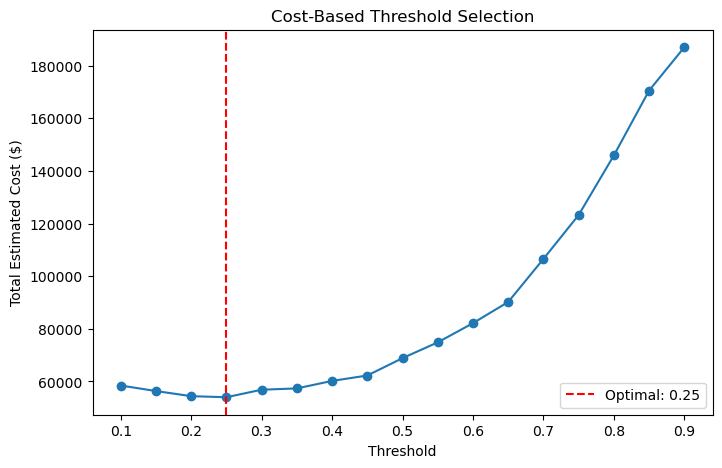

In [24]:
# Assumptions: cost of a retention offer vs. cost of losing a customer
COST_RETENTION_OFFER = 50      # cost of reaching out / discount given
COST_LOST_CUSTOMER = 500       # estimated lifetime value lost if churn isn't prevented

thresholds_to_test = np.arange(0.1, 0.91, 0.05)
results = []

for t in thresholds_to_test:
    preds = (rf_probs >= t).astype(int)
    tp = ((preds == 1) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    fn = ((preds == 0) & (y_test == 1)).sum()

    # Cost: false negatives lose the customer; true+false positives cost a retention offer
    total_cost = fn * COST_LOST_CUSTOMER + (tp + fp) * COST_RETENTION_OFFER
    results.append({'threshold': t, 'tp': tp, 'fp': fp, 'fn': fn, 'total_cost': total_cost})

cost_df = pd.DataFrame(results)
best_row = cost_df.loc[cost_df['total_cost'].idxmin()]
print(cost_df.to_string(index=False))
print(f"\nOptimal cost-based threshold: {best_row['threshold']:.2f} (Total cost: ${best_row['total_cost']:,.0f})")

plt.figure(figsize=(8, 5))
plt.plot(cost_df['threshold'], cost_df['total_cost'], marker='o')
plt.axvline(x=best_row['threshold'], color='red', linestyle='--', label=f"Optimal: {best_row['threshold']:.2f}")
plt.xlabel('Threshold')
plt.ylabel('Total Estimated Cost ($)')
plt.title('Cost-Based Threshold Selection')
plt.legend()
plt.show()

In [26]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_model, X_test_scaled, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc'
)

perm_importance_df = pd.DataFrame({
    'Feature': X_test_scaled.columns,
    'Importance': perm_result.importances_mean
}).sort_values('Importance', ascending=False).head(10)

print("--- Top 10 Features by Permutation Importance ---")
print(perm_importance_df.to_string(index=False))

# Quick comparison note: check if top SHAP features overlap with top permutation features
shap_mean_abs = np.abs(shap_values_churn).mean(axis=0)
shap_top10 = X_test_scaled.columns[np.argsort(shap_mean_abs)[::-1][:10]].tolist()
perm_top10 = perm_importance_df['Feature'].tolist()
overlap = set(shap_top10) & set(perm_top10)
print(f"\nOverlap between SHAP top-10 and Permutation top-10: {len(overlap)}/10")
print(overlap)

--- Top 10 Features by Permutation Importance ---
                       Feature  Importance
                        tenure    0.052520
             Contract_Two year    0.044517
   InternetService_Fiber optic    0.018372
             Contract_One year    0.017072
                MonthlyCharges    0.003918
            OnlineSecurity_Yes    0.003137
               TechSupport_Yes    0.002292
PaymentMethod_Electronic check    0.002150
          PaperlessBilling_Yes    0.001196
            InternetService_No    0.000986

Overlap between SHAP top-10 and Permutation top-10: 10/10
{'OnlineSecurity_Yes', 'InternetService_Fiber optic', 'Contract_Two year', 'TechSupport_Yes', 'tenure', 'PaperlessBilling_Yes', 'MonthlyCharges', 'InternetService_No', 'PaymentMethod_Electronic check', 'Contract_One year'}


In [28]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Use the same preprocessing logic as the final model, but let CV handle the splits
# Note: scaler is refit inside each fold conceptually via the pipeline pattern below
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

cv_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('xgb', XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    cv_pipeline, X, y,
    cv=skf,
    scoring=['roc_auc', 'average_precision'],
    n_jobs=-1
)

print("--- 5-Fold Stratified Cross-Validation (XGBoost) ---")
print(f"ROC-AUC: {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"PR-AUC:  {cv_results['test_average_precision'].mean():.4f} ± {cv_results['test_average_precision'].std():.4f}")
print(f"\nPer-fold ROC-AUC: {np.round(cv_results['test_roc_auc'], 4)}")
print(f"Per-fold PR-AUC:  {np.round(cv_results['test_average_precision'], 4)}")

--- 5-Fold Stratified Cross-Validation (XGBoost) ---
ROC-AUC: 0.8382 ± 0.0109
PR-AUC:  0.6496 ± 0.0206

Per-fold ROC-AUC: [0.8544 0.8331 0.8476 0.8265 0.8291]
Per-fold PR-AUC:  [0.6604 0.6513 0.6803 0.6198 0.6362]


In [ ]:
## Summary & Business Recommendation

Three models were compared on this 26.5% churn dataset: Logistic Regression as a diagnostic 
baseline, Random Forest, and XGBoost. The modest gap between linear and tree-based performance 
(ROC-AUC 0.838 vs 0.841 vs 0.835; PR-AUC 0.628 vs 0.640 vs 0.646) suggests churn risk is mostly 
driven by a few strongly separating features, with a smaller layer of interaction effects that 
ensembles capture more faithfully. SHAP and permutation importance independently agreed on the 
top 10 churn drivers (10/10 overlap), with `tenure`, `Contract` length, and `InternetService_Fiber 
optic` consistently ranked highest by both methods — giving two independent forms of evidence 
that these features genuinely drive the model's predictions rather than reflecting an artifact of 
one interpretation method. The SHAP dependence plot further confirmed an interaction effect: 
fiber optic customers carry slightly elevated churn risk relative to non-fiber customers at the 
same tenure level, particularly in the early-tenure range.

At the segment level, month-to-month contract customers with fiber optic internet churn at over 
55%, compared to roughly 1-2% for two-year contract customers on DSL or no internet service — 
the single clearest actionable pattern in the data.

Two decision thresholds are reported because they answer different business questions: the 
recall-targeted threshold (~80% recall) is appropriate if the priority is catching as many 
likely churners as possible regardless of outreach cost, while the cost-based threshold (0.25, 
minimizing total estimated cost across reasonable retention-offer-vs-lost-customer assumptions) 
is appropriate if the priority is minimizing net financial loss. In practice, the cost-based 
threshold would be the recommended default for a retention campaign, with the recall-targeted 
threshold reserved for periods where customer retention is prioritized over short-term cost 
(e.g. before a price increase rollout).

5-fold stratified cross-validation confirms these results are stable across different data 
splits rather than an artifact of one particular train/test partition.